In [10]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statistics

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import sklearn 
import sklearn.datasets
import sklearn.cross_decomposition
import sklearn.decomposition
import sklearn.neighbors
import sklearn.metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler

import ipympl

%matplotlib widget

file_path = 'Cafe_2022_for_ANN.csv'
df = pd.read_csv(file_path)
df.set_index('ts', inplace=True)
display(df)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [11]:
X3 = df.drop('kW',axis = 1)
y3 = df.kW

scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
# display(y3_test)

#kNN regression
from sklearn.neighbors import KNeighborsRegressor
# Create KNN classifier
knn = KNeighborsRegressor(n_neighbors = 3)
# Fit the classifier to the data
# lab_enc = preprocessing.LabelEncoder()
# encoded = lab_enc.fit_transform(y3_train)

# Need to convert to int for regressor to work
knn.fit(X3_train, np.ravel(y3_train))

from sklearn.model_selection import GridSearchCV
#create new a knn model
knn2 = KNeighborsRegressor()
#create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 25)}
#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)
#fit model to data
knn_gscv.fit(X3_train, y3_train)

y3_predict_train = knn_gscv.predict(X3_train)
y3_predict_test = knn_gscv.predict(X3_test)

In [12]:
y3_train.info(())

y_train_sorted = y3_train.sort_index()
y_test_sorted = y3_test.sort_index()

<class 'pandas.core.series.Series'>
Index: 27952 entries, 2022-03-04 01:45:00+00:00 to 2022-06-15 12:45:00+00:00
dtypes: float64(1)
memory usage: 1.4+ MB


{'n_neighbors': 7}
0.4832363177949393


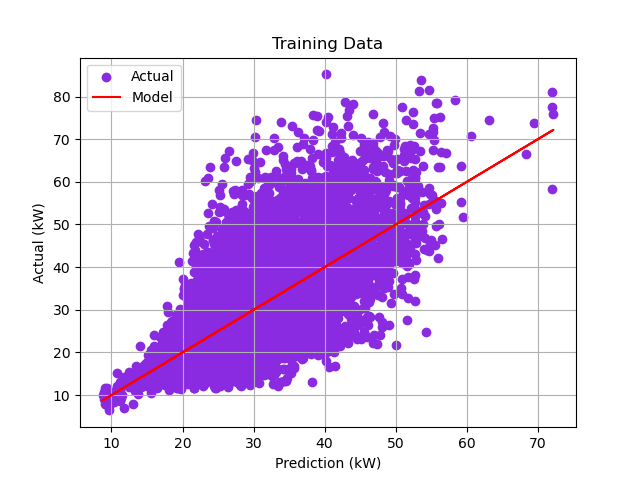

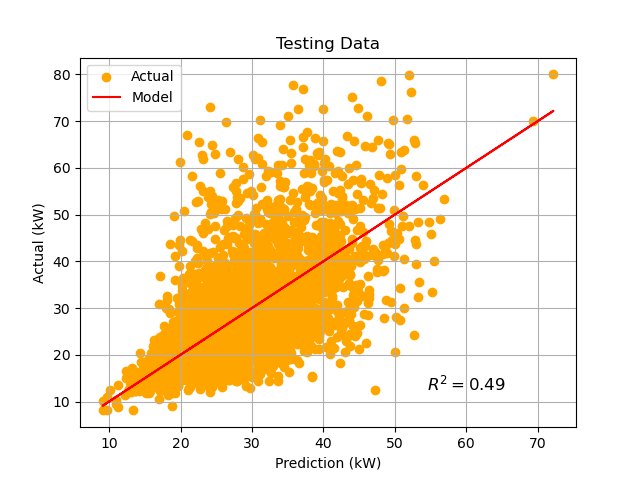

In [13]:
# kNN metrics, plot data vs predictions (training and testing)

#check top performing n_neighbors value
print(knn_gscv.best_params_)

#check mean score for the top performing value of n_neighbors
print(knn_gscv.best_score_)

fig, ax = plt.subplots()
ax.scatter(y3_predict_train,y3_train, c='blueviolet', label='Actual')
ax.plot(y3_predict_train, y3_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()

fig,ax = plt.subplots()
ax.scatter(y3_predict_test, y3_test, c='orange', label='Actual')
ax.plot(y3_predict_test, y3_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
r_squared = sklearn.metrics.r2_score(y3_test, y3_predict_test)
ax.annotate(f'$R^2 = {r_squared:.2f}$', xy=(0.7, 0.1), xycoords='axes fraction', fontsize=12)
ax.legend()
ax.grid()

In [14]:
# Error Evaluation 
# Training error 
print("Train R^2:", sklearn.metrics.r2_score(y3_train, y3_predict_train))
print("kNN root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(np.ravel(y3_train), np.ravel(y3_predict_train), squared=False))
print("MAE:", mean_absolute_error(y3_train, y3_predict_train))
print("kNN CV value: ", (((statistics.stdev(np.ravel(y3_train) - np.ravel(y3_predict_train)))/statistics.mean(np.ravel(y3_train) - np.ravel(y3_predict_train)))))

# Test Error
print("\nTest R^2:", sklearn.metrics.r2_score(y3_test, y3_predict_test))
print("MAE:", mean_absolute_error(y3_test, y3_predict_test))
print("kNN root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(np.ravel(y3_test), np.ravel(y3_predict_test), squared=False))
print("kNN CV value: ", (((statistics.stdev(np.ravel(y3_test) - np.ravel(y3_predict_test)))/statistics.mean(np.ravel(y3_test) - np.ravel(y3_predict_test)))))

Train R^2: 0.6287386341474317
kNN root mean squared error: 5.54
MAE: 3.31701274376668
kNN CV value:  261.44196607303206

Test R^2: 0.4917675910738962
MAE: 3.8665770010393548
kNN root mean squared error: 6.48
kNN CV value:  75.17258680182019


In [15]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y3_train, y3_predict_train))
print("MSE:", mean_squared_error(y3_train, y3_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y3_train, y3_predict_train)))
print("MAE:", mean_absolute_error(y3_train, y3_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y3_train ,y3_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y3_test, y3_predict_test))
print("MSE:", mean_squared_error(y3_test, y3_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y3_test, y3_predict_test)))
print("MAE:", mean_absolute_error(y3_test, y3_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y3_test, y3_predict_test))

Train Data
R^2: 0.6287386341474317
MSE: 30.70291997382872
Root MSE: 5.541021564100678
MAE: 3.31701274376668
MAPE: % 0.12471137488512991
 
Test Data
R^2: 0.4917675910738962
MSE: 41.98526488940085
Root MSE: 6.479603760215655
MAE: 3.8665770010393548
MAPE: % 0.1443173568103365
